In [41]:
#Importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score


In [42]:
df = pd.read_csv('Maintenance.csv')
df.head()

,Timestamp,Machine_ID,Shift,Operator_ID,Material_Type,Machine_Age_Hours,Temperature_C,Vibration_mm_s,Pressure_bar,Rotation_RPM,Oil_Level_Pct,Power_Consumption_kW,Production_Output_units_hr,Defect_Rate_Pct,Downtime_Last30d_hrs,Days_Since_Maintenance,Failure_Within_7Days
0,2023-01-01 00:00:00,Lathe-02,Morning,OP-003,Cast_Iron,5541,78.15,3.882,6.53,1397.9,96.1,23.21,103.5,1.834,7.7,95,0
1,2023-01-01 06:00:00,Press-01,Afternoon,OP-007,Titanium_6Al4V,2091,70.84,1.489,6.22,1389.1,87.8,21.61,128.2,0.809,5.5,43,0
2,2023-01-01 12:00:00,Weld-01,Afternoon,OP-014,Cast_Iron,5209,78.20,3.034,6.43,1431.7,58.4,23.58,102.5,2.135,12.6,79,0
3,2023-01-01 18:00:00,Press-02,Night,OP-007,Titanium_6Al4V,4985,72.37,3.368,7.42,1434.2,16.4,22.96,126.4,1.804,9.8,55,1
4,2023-01-02 00:00:00,Lathe-02,Morning,OP-005,Aluminum_6061,5541,77.33,3.301,5.59,1363.7,93.8,20.71,108.9,2.087,7.8,137,0


EDA

1. Checking for missing data and if there is, filling the missing data.

In [43]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Timestamp                   1200 non-null   str    
 1   Machine_ID                  1200 non-null   str    
 2   Shift                       1200 non-null   str    
 3   Operator_ID                 1200 non-null   str    
 4   Material_Type               1200 non-null   str    
 5   Machine_Age_Hours           1200 non-null   int64  
 6   Temperature_C               1160 non-null   float64
 7   Vibration_mm_s              1171 non-null   float64
 8   Pressure_bar                1200 non-null   float64
 9   Rotation_RPM                1200 non-null   float64
 10  Oil_Level_Pct               1167 non-null   float64
 11  Power_Consumption_kW        1158 non-null   float64
 12  Production_Output_units_hr  1200 non-null   float64
 13  Defect_Rate_Pct             1200 non-null   

In [44]:
#Fill missing values with mean for numerical columns
missing_cols = ['Vibration_mm_s', 'Oil_Level_Pct', 'Power_Consumption_kW', 'Temperature_C']
for col in missing_cols:
    df[col] = df[col].fillna(df[col].mean())

In [45]:
#Check the info again to confirm no missing values remain
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Timestamp                   1200 non-null   str    
 1   Machine_ID                  1200 non-null   str    
 2   Shift                       1200 non-null   str    
 3   Operator_ID                 1200 non-null   str    
 4   Material_Type               1200 non-null   str    
 5   Machine_Age_Hours           1200 non-null   int64  
 6   Temperature_C               1200 non-null   float64
 7   Vibration_mm_s              1200 non-null   float64
 8   Pressure_bar                1200 non-null   float64
 9   Rotation_RPM                1200 non-null   float64
 10  Oil_Level_Pct               1200 non-null   float64
 11  Power_Consumption_kW        1200 non-null   float64
 12  Production_Output_units_hr  1200 non-null   float64
 13  Defect_Rate_Pct             1200 non-null   

2. Checking for outliers 

In [46]:
outlier_report = []
num_cols = df.select_dtypes(include=['number']).columns
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Count how many rows fall outside the boundaries
    outlier_count = df[(df[col] < lower_bound) | (df[col] > upper_bound)].shape[0]
    outlier_pct = (outlier_count / df.shape[0]) * 100
    
    outlier_report.append({
        'Column': col,
        'Outlier Count': outlier_count,
        'Percentage (%)': round(outlier_pct, 2),
        'Lower Bound': round(lower_bound, 2),
        'Upper Bound': round(upper_bound, 2)
    })

# Convert the results into a clean, scannable DataFrame
report_df = pd.DataFrame(outlier_report)
print(report_df.to_string(index=False))

                    Column  Outlier Count  Percentage (%)  Lower Bound  Upper Bound
         Machine_Age_Hours              0            0.00     -4997.50     10974.50
             Temperature_C              8            0.67        54.46        97.27
            Vibration_mm_s              5            0.42        -0.23         5.61
              Pressure_bar              6            0.50         4.32         8.72
              Rotation_RPM             14            1.17      1232.10      1666.10
             Oil_Level_Pct              0            0.00       -57.85       138.75
      Power_Consumption_kW              4            0.33        15.78        28.00
Production_Output_units_hr              7            0.58        78.56       134.66
           Defect_Rate_Pct              0            0.00        -0.02         3.48
      Downtime_Last30d_hrs             34            2.83        -1.90        15.70
    Days_Since_Maintenance              0            0.00       -89.50      

Visualizing the outliers using boxplot.

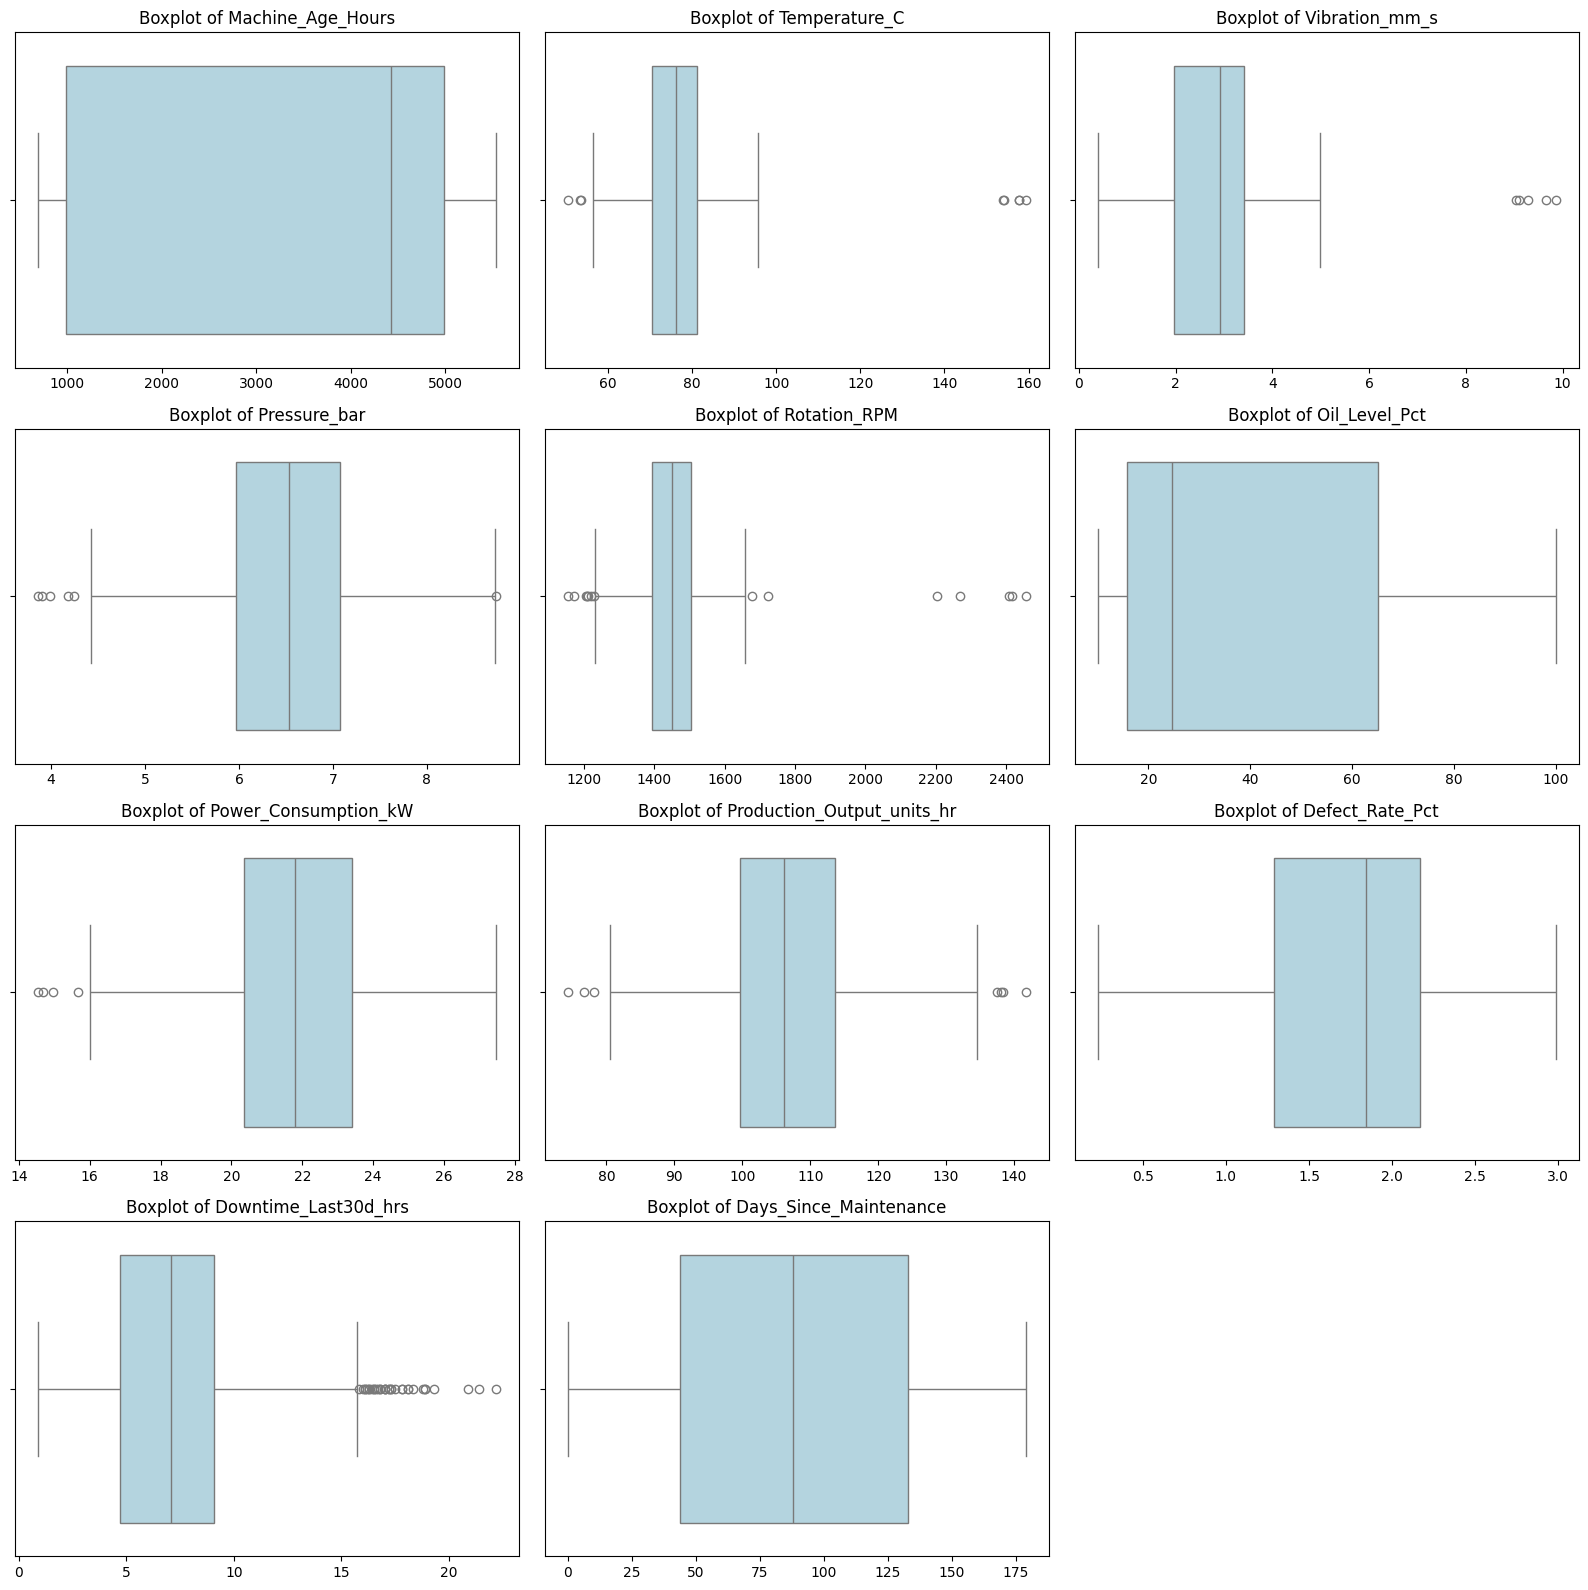

In [47]:
# Automatically find all numerical columns (excluding IDs/Targets)
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Remove ID, target, or binary columns you don't want to check
cols_to_ignore = ['Failure_Within_7Days']  
num_cols = [c for c in num_cols if c not in cols_to_ignore]

# Set up a grid dynamically based on the number of columns
num_plots = len(num_cols)
fig, axes = plt.subplots(nrows=(num_plots + 2) // 3, ncols=3, figsize=(16, 4 * ((num_plots + 2) // 3)))
axes = axes.flatten()

# Loop through and plot each column
for i, col in enumerate(num_cols):
    sns.boxplot(x=df[col], ax=axes[i], color='lightblue')
    axes[i].set_title(f'Boxplot of {col}', fontsize=12)
    axes[i].set_xlabel('')

# Hide any empty subplot boxes
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


3. Feature engineering the requested Columns
The following features were requested by the contractor. The features are;
a. Hours_since_maintenance
b. Temp_vib_interaction
c. Rolling_avg_7d

In [48]:
# 1. Ensure Timestamp is in datetime format so the rolling window works correctly
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

# 2. Add 'Hours_since_maintenance'
df['Hours_since_maintenance'] = df['Days_Since_Maintenance'] * 24

# 3. Add 'Temp_vib_interaction'
df['Temp_vib_interaction'] = df['Temperature_C'] * df['Vibration_mm_s']

# 4. Add 'Rolling_avg_7d' (grouped by machine so historical data does not mix)
df['Rolling_avg_7d'] = (
    df.groupby('Machine_ID')
    .rolling(window='7D', on='Timestamp', min_periods=1)['Temperature_C']
    .mean()
    .reset_index(level=0, drop=True)
)
# View your final dataset with just these new additions
print(df[['Hours_since_maintenance', 'Temp_vib_interaction', 'Rolling_avg_7d']].head())


   Hours_since_maintenance  Temp_vib_interaction  Rolling_avg_7d
0                     2280             303.37830             NaN
1                     1032             105.48076             NaN
2                     1896             237.25880             NaN
3                     1320             243.74216             NaN
4                     3288             255.26633             NaN


In [49]:
#Backward fill
df['Rolling_avg_7d'] = df['Rolling_avg_7d'].ffill()

Confirming these columns have been added to my dataframe

In [50]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   Timestamp                   1200 non-null   datetime64[us]
 1   Machine_ID                  1200 non-null   str           
 2   Shift                       1200 non-null   str           
 3   Operator_ID                 1200 non-null   str           
 4   Material_Type               1200 non-null   str           
 5   Machine_Age_Hours           1200 non-null   int64         
 6   Temperature_C               1200 non-null   float64       
 7   Vibration_mm_s              1200 non-null   float64       
 8   Pressure_bar                1200 non-null   float64       
 9   Rotation_RPM                1200 non-null   float64       
 10  Oil_Level_Pct               1200 non-null   float64       
 11  Power_Consumption_kW        1200 non-null   float64       
 12  Pro

In [51]:
# The exact list of columns in the order you requested
ordered_columns = [
    'Timestamp',
    'Machine_ID',
    'Shift',
    'Operator_ID',
    'Material_Type',
    'Machine_Age_Hours',
    'Temperature_C',
    'Vibration_mm_s',
    'Pressure_bar',
    'Rotation_RPM',
    'Oil_Level_Pct',
    'Power_Consumption_kW',
    'Production_Output_units_hr',
    'Defect_Rate_Pct',
    'Downtime_Last30d_hrs',
    'Days_Since_Maintenance',
    'Hours_since_maintenance',
    'Temp_vib_interaction',
    'Rolling_avg_7d',
    'Failure_Within_7Days'  # Forced to the last spot
]
# Apply the new column order to your DataFrame
df = df[ordered_columns]

# Verify the final column order
print(df.columns.tolist())


['Timestamp', 'Machine_ID', 'Shift', 'Operator_ID', 'Material_Type', 'Machine_Age_Hours', 'Temperature_C', 'Vibration_mm_s', 'Pressure_bar', 'Rotation_RPM', 'Oil_Level_Pct', 'Power_Consumption_kW', 'Production_Output_units_hr', 'Defect_Rate_Pct', 'Downtime_Last30d_hrs', 'Days_Since_Maintenance', 'Hours_since_maintenance', 'Temp_vib_interaction', 'Rolling_avg_7d', 'Failure_Within_7Days']


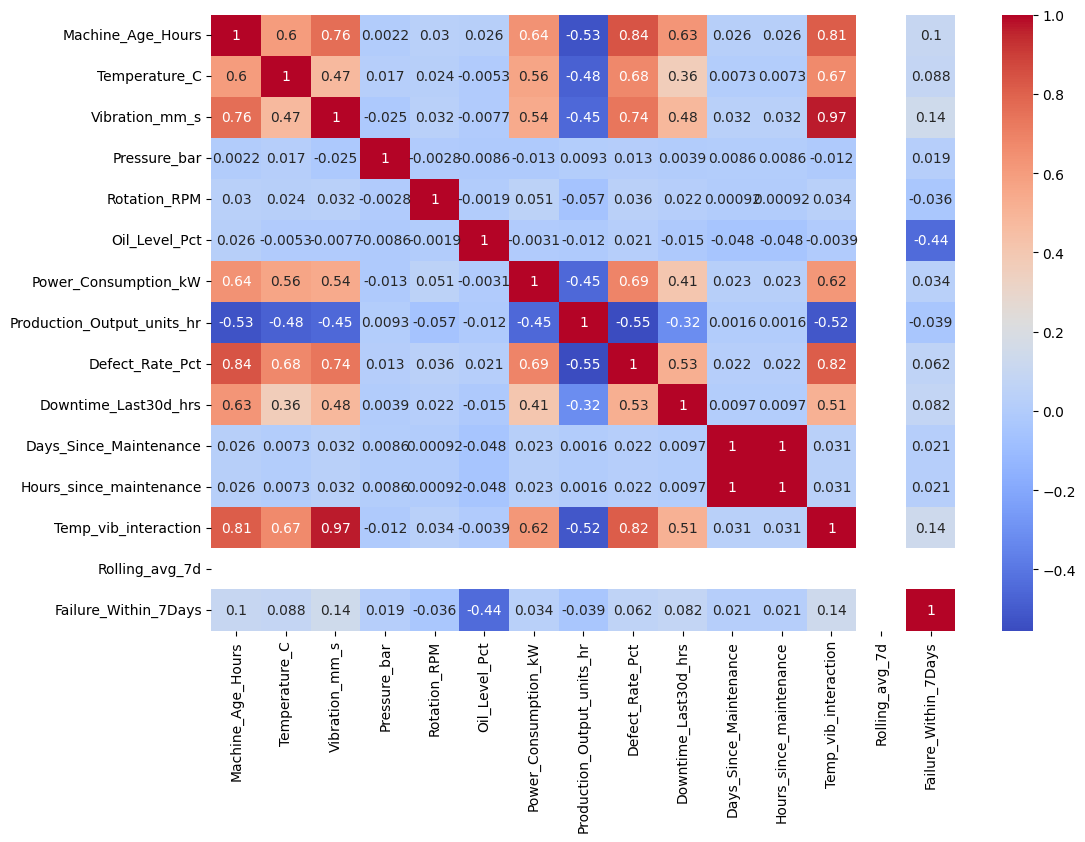

In [52]:
# Select only numeric columns
numeric_df = df.select_dtypes(include=['number'])

# Compute correlation matrix
corr_matrix = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.show()


In [53]:
df.head()

,Timestamp,Machine_ID,Shift,Operator_ID,Material_Type,Machine_Age_Hours,Temperature_C,Vibration_mm_s,Pressure_bar,Rotation_RPM,Oil_Level_Pct,Power_Consumption_kW,Production_Output_units_hr,Defect_Rate_Pct,Downtime_Last30d_hrs,Days_Since_Maintenance,Hours_since_maintenance,Temp_vib_interaction,Rolling_avg_7d,Failure_Within_7Days
0,2023-01-01 00:00:00,Lathe-02,Morning,OP-003,Cast_Iron,5541,78.15,3.882,6.53,1397.9,96.1,23.21,103.5,1.834,7.7,95,2280,303.37830,NaN,0
1,2023-01-01 06:00:00,Press-01,Afternoon,OP-007,Titanium_6Al4V,2091,70.84,1.489,6.22,1389.1,87.8,21.61,128.2,0.809,5.5,43,1032,105.48076,NaN,0
2,2023-01-01 12:00:00,Weld-01,Afternoon,OP-014,Cast_Iron,5209,78.20,3.034,6.43,1431.7,58.4,23.58,102.5,2.135,12.6,79,1896,237.25880,NaN,0
3,2023-01-01 18:00:00,Press-02,Night,OP-007,Titanium_6Al4V,4985,72.37,3.368,7.42,1434.2,16.4,22.96,126.4,1.804,9.8,55,1320,243.74216,NaN,1
4,2023-01-02 00:00:00,Lathe-02,Morning,OP-005,Aluminum_6061,5541,77.33,3.301,5.59,1363.7,93.8,20.71,108.9,2.087,7.8,137,3288,255.26633,NaN,0


In [63]:
x = df[['Machine_Age_Hours', 'Temperature_C', 'Vibration_mm_s', 'Oil_Level_Pct', 'Days_Since_Maintenance']].values
y = df['Failure_Within_7Days'].values

In [64]:
print(x.shape, y.shape)
print(x)
print(y)

(1200, 5) (1200,)
[[5.5410000e+03 7.8150000e+01 3.8820000e+00 9.6100000e+01 9.5000000e+01]
 [2.0910000e+03 7.0840000e+01 1.4890000e+00 8.7800000e+01 4.3000000e+01]
 [5.2090000e+03 7.8200000e+01 3.0340000e+00 5.8400000e+01 7.9000000e+01]
 ...
 [9.2300000e+02 7.1200000e+01 2.7474953e+00 2.5100000e+01 2.0000000e+00]
 [4.4240000e+03 8.9130000e+01 3.6950000e+00 2.7000000e+01 7.1000000e+01]
 [4.9850000e+03 8.3430000e+01 3.5280000e+00 1.0000000e+01 1.0000000e+01]]
[0 0 0 ... 0 0 1]


In [65]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

In [66]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(x_train)
X_test_scaled = scaler.transform(x_test)

# 4. Find the optimal number of components
pca_full = PCA()
pca_full.fit(X_train_scaled)

# Check cumulative variance
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)
print("Cumulative variance by component:\n", cumulative_variance)



Cumulative variance by component:
 [0.46213195 0.67510702 0.86171247 0.95719554 1.        ]


In [77]:

# 5. Apply PCA with your chosen number of components (e.g., 7 components)
# Alternatively, pass a float (e.g., PCA(n_components=0.90)) to automatically choose 
# the number of components that retain 90% of the variance.
pca = PCA(n_components=3) 

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# X_train_pca now has 3 columns instead of 5. You can feed this into your model!

Creating the model using random forest classifier

In [78]:
maintenance = LogisticRegression(class_weight='balanced', random_state=42)
maintenance.fit(X_train_pca, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

Evaluating the model

In [79]:
y_pred = maintenance.predict(X_test_pca)

In [80]:
print(confusion_matrix(y_test, y_pred))
print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("ROC AUC Score:", roc_auc_score(y_test, maintenance.predict_proba(X_test_pca)[:, 1]))
    

[[90 52]
 [13 85]]
0.7291666666666666
              precision    recall  f1-score   support

           0       0.87      0.63      0.73       142
           1       0.62      0.87      0.72        98

    accuracy                           0.73       240
   macro avg       0.75      0.75      0.73       240
weighted avg       0.77      0.73      0.73       240

ROC AUC Score: 0.7831273354412187


In [ ]:
features = ['Machine_Age_Hours', 'Temperature_C', 'Vibration_mm_s', 'Oil_Level_Pct', 'Days_Since_Maintenance']
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': maintenance.coef_[0]  # For Logistic Regression, use coef_ instead of feature_importances_
}).sort_values('Importance', ascending=False)
print(importance_df)

ValueError: All arrays must be of the same length